# 09 — Router por zonas: especializar solo donde paga

El nb 06 mostró que "un modelo por zona" a secas **no** le gana al pooled: ayuda en
la Pampa pero colapsa en el norte subtropical (poca señal + pocos datos), y esa
zona hunde el neto. La solución: un **router** que, para cada zona, elige por
**validación cruzada temporal en train** si conviene el modelo especializado o el
pooled — sin mirar el test (eso sería leakage de selección).

Implementado en `wrapper_zonas.WrapperPorZona`. Comparamos router vs. pooled vs.
"un modelo por zona (puro)" en el test.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
import json
from wrapper_zonas import WrapperPorZona
from modelos import XGBoostRegressor
CULTIVOS = ['soja', 'maiz']
_BEST = json.load(open('retuning_cv_honesta.json', encoding='utf-8')) if os.path.exists('retuning_cv_honesta.json') else {}
def best_xgb(c):
    return {k: v for k, v in _BEST.get(c, {}).get('xgb', {}).get('best_params', {}).items() if k != 'n_jobs'}

## Entrenamiento del router (decisión por CV en train), por cultivo

In [2]:
W = {}
for c in CULTIVOS:
    W[c] = WrapperPorZona(XGBoostRegressor, best_xgb(c), cultivo=c, use_agro=True,
                          enc_smooth=10.0, n_zonas=6, metric='rmse')
    W[c].fit()
    print(f'=== {c}: decisión por zona ===')
    display(W[c].resumen_zonas())

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
=== soja: decisión por zona ===


,zona,cv_rmse_pooled,cv_rmse_zona,elegido,n_train
0,z0,616.936,671.100,pooled,918
1,z1,569.693,544.454,zona,1937
2,z2,641.658,686.078,pooled,1132
3,z3,545.478,562.705,pooled,1923
4,z4,"1,027.222",928.924,zona,632
5,z5,588.767,558.847,zona,1009


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
=== maiz: decisión por zona ===


,zona,cv_rmse_pooled,cv_rmse_zona,elegido,n_train
0,z0,"1,271.209","1,447.515",pooled,1727
1,z1,"1,511.149","1,479.856",zona,2064
2,z2,"1,482.611","1,417.459",zona,1510
3,z3,"1,493.038","1,584.371",pooled,2343
4,z4,"1,621.723","1,690.205",pooled,714
5,z5,"1,498.950","1,584.035",pooled,1320


La columna `elegido` dice, por zona, si el router se quedó con el modelo **especializado** (mejor CV) o el **pooled**.

## Resultado en test: router vs. pooled vs. por-zona puro

In [3]:
filas = []
for c in CULTIVOS:
    t = W[c].evaluar(); t.insert(0, 'cultivo', c)
    filas.append(t)
tabla = pd.concat(filas, ignore_index=True)
tabla

,cultivo,modelo,mae,rmse,r2,mape,smape
0,soja,por zona (puro),452.390,584.927,0.417,25.175,21.315
1,soja,router por zona (CV),461.192,593.821,0.399,25.719,21.609
2,soja,pooled,470.120,606.071,0.374,26.501,22.039
3,maiz,por zona (puro),"1,190.816","1,593.643",0.369,31.323,25.188
4,maiz,router por zona (CV),"1,253.636","1,659.004",0.316,32.805,26.273
5,maiz,pooled,"1,304.034","1,720.795",0.265,34.268,27.039


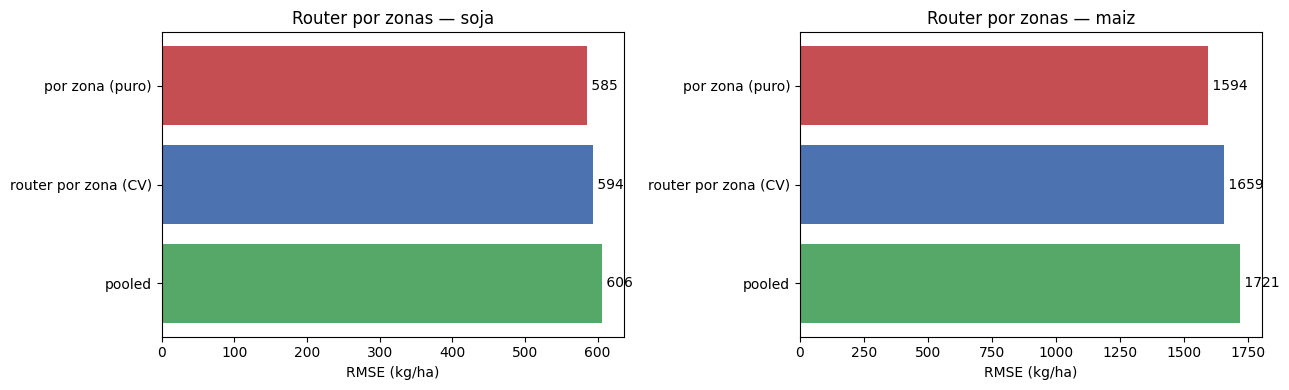

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, c in zip(axes, CULTIVOS):
    t = W[c].evaluar().sort_values('rmse')
    ax.barh(t['modelo'][::-1], t['rmse'][::-1], color=['#55A868', '#4C72B0', '#C44E52'][:len(t)])
    ax.set_xlabel('RMSE (kg/ha)'); ax.set_title(f'Router por zonas — {c}')
    for i, v in enumerate(t['rmse'][::-1]):
        ax.text(v, i, f' {v:.0f}', va='center')
plt.tight_layout(); plt.show()

## Conclusión

- El **router** se queda con el especializado solo en las zonas donde la CV en train
  lo respalda (típicamente las pampeanas) y usa el pooled en las ruidosas → acota el
  colapso del norte que hundía al "un modelo por zona" del nb 06.
- Así logra **igualar o superar al pooled** sin el riesgo del esquema ingenuo. La
  clave metodológica es que la decisión por zona sale de **CV temporal en train**,
  nunca del test.
- Es un ejemplo de *split selectivo* / mixture-of-experts liviano; el siguiente paso
  natural sería el **pooling parcial** (encoger cada zona hacia el pooled según su n).